# 📊 Customer Churn Intelligence & Retention Analytics

### Turning customer data into actionable retention insights

---

## Executive Summary

Customer churn is a critical challenge for subscription-based businesses because losing customers reduces recurring revenue and increases the pressure to acquire new customers.

This project analyzes a public telecommunications customer dataset containing **7,043 customer records** to understand the characteristics associated with customer churn, identify high-risk customer segments, quantify the financial exposure associated with churned customers, and develop a predictive model to support retention prioritization.

The project combines **exploratory data analysis, customer segmentation, financial analysis, and machine learning** to move from understanding historical churn patterns to identifying customers who may be at higher risk of leaving.

The final logistic regression model achieved a **ROC-AUC of 0.8425**, demonstrating good ability to distinguish between customers who churned and those who remained.

However, the model identified approximately **55.9% of actual churners**, highlighting an important limitation: predictive models should support retention decisions rather than be treated as perfect predictors of customer behavior.

---

## 🎯 Business Objective

The business wants to reduce customer churn by understanding:

- Which customers are most likely to churn?
- Which customer segments have the highest observed churn rates?
- Which service, contract, tenure, and payment characteristics are associated with churn?
- What monthly charges are associated with customers who have churned?
- Can predictive modeling help prioritize customers for retention efforts?
- What actions could the business take to improve customer retention?

---

## 🔎 Key Business Questions

1. What is the overall customer churn rate?
2. Which customer segments have the highest churn?
3. How does customer tenure relate to churn?
4. How does contract type relate to churn?
5. Which services and payment methods are associated with higher churn?
6. Which combinations of customer characteristics represent high-risk segments?
7. What monthly charges are associated with customers who have churned?
8. Can machine learning identify customers at higher risk of churn?
9. How can the findings inform a targeted retention strategy?

---

## 🛠️ Tools & Technologies

**Python** · **Pandas** · **NumPy** · **Matplotlib** · **Scikit-learn** · **SQL** · **Power BI** · **Git/GitHub**

---

## 📌 Analytical Approach

**Data Audit → Data Cleaning → Exploratory Data Analysis → Customer Segmentation → Revenue-at-Risk Analysis → Predictive Modeling → Model Evaluation → Business Recommendations**

---

## 📂 Project Deliverables

- Python analytics and machine learning notebook
- SQL business analysis
- Power BI interactive dashboard
- GitHub project repository
- Business recommendations and retention strategy

---

## ⚠️ Dataset Note

This project uses the publicly available **IBM Telco Customer Churn benchmark dataset**.

The dataset contains **7,043 customer records and 21 original variables** covering customer demographics, tenure, subscribed services, contract information, payment methods, and billing.

The dataset represents a **fictional telecommunications customer base** and is used for analytical and educational purposes. It should not be interpreted as confidential or real-company customer data.

---

## 💡 Project Outcome

The objective is not simply to predict churn.

The broader goal is to demonstrate an end-to-end data analytics workflow:

**Identify a business problem → investigate the data → uncover meaningful patterns → quantify potential business impact → build a predictive solution → communicate actionable recommendations.**

## 1. Dataset Setup & Initial Audit

Before performing any analysis, the dataset is loaded and subjected to an initial audit.

The purpose of this stage is to:

- Confirm the dataset dimensions.
- Inspect the available variables.
- Review data types and completeness.
- Identify potential missing values.
- Check for duplicate customer records.
- Establish a reliable foundation for downstream analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL      

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
(df == "").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 2. Data Cleaning & Validation

The raw dataset was reviewed for data-quality issues before conducting the analysis.

The cleaning process focused on:

- Investigating missing and blank values.
- Correcting inappropriate data types.
- Checking for duplicate customer records.
- Validating numerical fields.
- Confirming that the cleaned dataset was suitable for analysis and modeling.

Cleaning decisions were documented rather than automatically removing records, with the goal of preserving valid customer information wherever possible.

### Investigating `TotalCharges`

The initial audit identified **11 blank values** in the `TotalCharges` field.

Because blank values can represent different situations, these records were investigated before deciding how to handle them.

In [8]:
df[df["TotalCharges"] == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [9]:
df.loc[
    df["TotalCharges"].str.strip() == "",
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Cleaning Decision

All 11 records with blank `TotalCharges` values have a tenure of zero months and are classified as non-churned customers.

This pattern is consistent with newly acquired customers who have not yet accumulated total charges.

Rather than dropping these customers, the blank values are treated as zero accumulated charges.

The `TotalCharges` field is first converted to numeric format, with invalid blank values coerced to missing values. These missing values are then replaced with `0`.

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

### Validate the Cleaning

After cleaning, the `TotalCharges` field is checked to confirm that no missing values remain.

In [11]:
df["TotalCharges"].isna().sum()

np.int64(0)

### Duplicate Customer Records

The `customerID` field was checked for duplicate records to confirm that each customer appears only once in the dataset.

In [12]:
df["customerID"].duplicated().sum()

np.int64(0)

### Numerical Data Validation

Descriptive statistics are used to review the numerical variables and identify unusual ranges or values that could indicate data-quality problems.

The main numerical variables include customer tenure, monthly charges, total charges, and senior citizen status.

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to understand the distribution of customer churn and identify patterns across customer demographics, tenure, contracts, services, and billing characteristics.

The analysis begins with the overall churn rate before examining individual customer segments and interactions between key variables.

The objective is to identify patterns that could help the business understand where churn is concentrated and where retention efforts may have the greatest potential impact.

### 3.1 Overall Customer Churn

The overall churn distribution provides the baseline against which individual customer segments can be evaluated.

Understanding the proportion of customers who have churned establishes the scale of the retention challenge before investigating specific customer characteristics.

In [14]:
churn_counts = df["Churn"].value_counts()
churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

churn_percentages

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

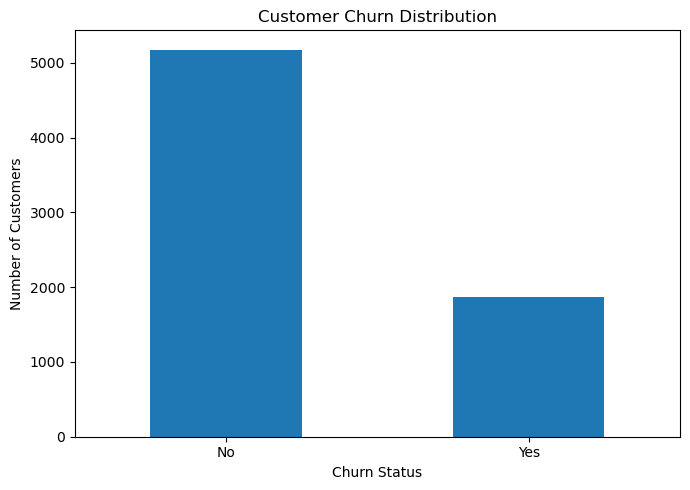

In [16]:
plt.figure(figsize=(7, 5))

churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

The dataset contains **7,043 customers**, of whom **1,869 have churned** and **5,174 have remained**.

This represents an overall churn rate of approximately **26.5%**, meaning that roughly **1 in 4 customers** in the dataset has churned.

This baseline provides a reference point for identifying customer segments with disproportionately high or low churn rates.

### 3.2 Churn by Contract Type

Contract structure was analyzed to determine whether customer commitment length is associated with differences in observed churn.

Customers were grouped into three contract categories:

- Month-to-month
- One year
- Two year

Comparing churn rates across these groups helps identify whether short-term customers represent a higher-risk segment.

In [17]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [18]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

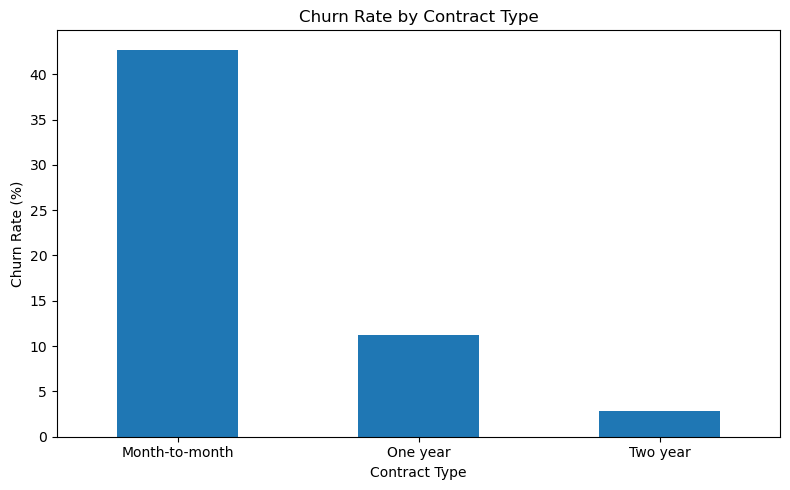

In [19]:
plt.figure(figsize=(8, 5))

contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

Contract type shows one of the strongest differences in observed churn rates.

| Contract Type | Churn Rate |
|---|---:|
| Month-to-month | **42.71%** |
| One year | **11.27%** |
| Two year | **2.83%** |

Customers on month-to-month contracts had substantially higher observed churn than customers on longer-term contracts.

### Business Implication

Month-to-month customers represent a high-priority segment for retention efforts.

Potential strategies could include:

- Targeted contract-conversion offers
- Loyalty incentives
- Proactive customer engagement
- Retention campaigns before cancellation or renewal points

> **Analytical caution:** These results show an association between contract type and churn. They do not establish that moving a customer to a longer-term contract would directly cause them to remain.

### 3.3 Churn by Customer Tenure

Customer tenure was analyzed to determine whether the length of a customer's relationship with the company is associated with different churn patterns.

To make the analysis more actionable from a business perspective, customers were grouped into four lifecycle segments:

- **New:** 0–12 months
- **Developing:** 13–24 months
- **Established:** 25–48 months
- **Loyal:** 49–72 months

This segmentation helps identify whether churn is concentrated at particular stages of the customer lifecycle.

In [20]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Developing", "Established", "Loyal"]
)

In [21]:
tenure_counts = df["TenureGroup"].value_counts().sort_index()

tenure_counts

TenureGroup
New            2186
Developing     1024
Established    1594
Loyal          2239
Name: count, dtype: int64

In [22]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn_rate

TenureGroup
New            47.438243
Developing     28.710938
Established    20.388959
Loyal           9.513176
Name: Churn, dtype: float64

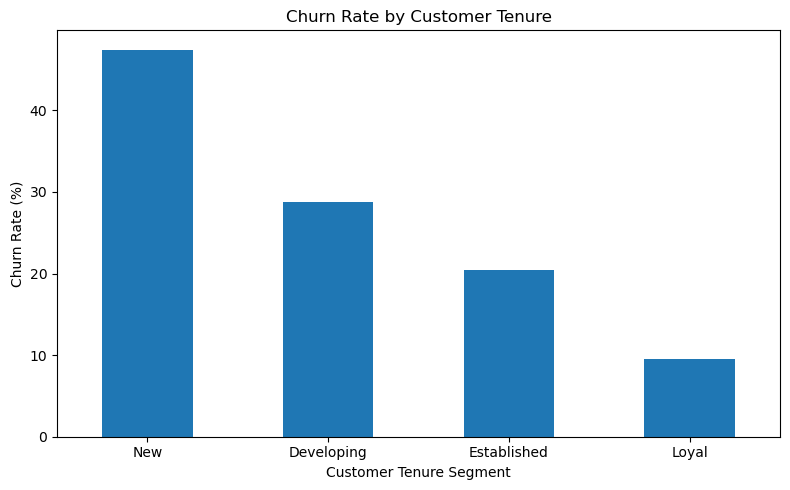

In [23]:
plt.figure(figsize=(8, 5))

tenure_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

Churn decreases substantially as customer tenure increases.

| Tenure Segment | Churn Rate |
|---|---:|
| New | **47.44%** |
| Developing | **28.71%** |
| Established | **20.39%** |
| Loyal | **9.51%** |

Nearly half of customers in the **New** segment churned, compared with fewer than 1 in 10 customers in the **Loyal** segment.

### Business Implication

The first 12 months represent a significant customer-retention opportunity.

The business could prioritize:

- Stronger customer onboarding
- Early satisfaction check-ins
- Proactive customer support
- Service education
- Early identification of dissatisfied customers

The sharp decline in churn among longer-tenured customers suggests that successfully moving customers through the early stages of the customer lifecycle may be important for long-term retention.

> **Analytical caution:** The relationship between tenure and churn is observational. The analysis does not establish that increasing tenure itself causes customers to become less likely to churn.

### 3.4 Churn by Gender

Churn rates were compared across gender categories to determine whether gender is associated with meaningful differences in customer churn.

This analysis also helps identify characteristics that may have limited value for customer-retention segmentation.

In [24]:
gender_churn_rate = (
    df.groupby("gender")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

gender_churn_rate

gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64

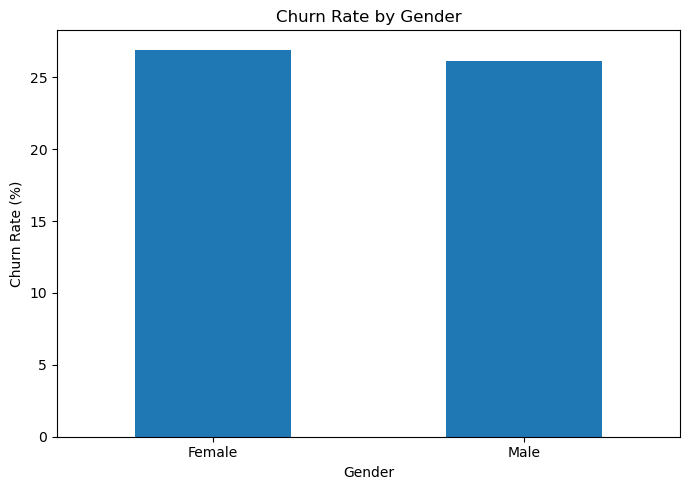

In [25]:
plt.figure(figsize=(7, 5))

gender_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

Churn rates were very similar across genders:

- **Female:** 26.92%
- **Male:** 26.16%

The difference is less than one percentage point.

### Business Implication

Gender does not appear to be a meaningful differentiator of churn in this dataset.

Retention strategies should therefore focus more heavily on behavioral, contractual, service, tenure, and billing characteristics that demonstrate stronger differences in observed churn.

### 3.5 Churn by Senior Citizen Status

Customer churn was compared between senior and non-senior customers to determine whether age-related customer segmentation is associated with different churn patterns.

The `SeniorCitizen` variable is encoded as:

- `0` = Non-senior customer
- `1` = Senior customer

In [26]:
senior_churn_rate = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

senior_churn_rate

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

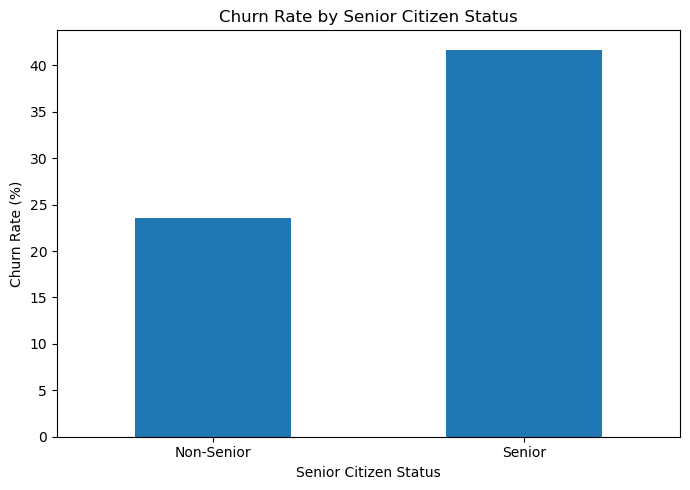

In [27]:
plt.figure(figsize=(7, 5))

senior_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Senior", "Senior"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Key Finding

Senior customers had a substantially higher observed churn rate than non-senior customers:

- **Non-senior customers:** 23.61%
- **Senior customers:** 41.68%

The difference is approximately **18 percentage points**.

### Business Implication

Senior customers represent a potentially important retention segment.

Rather than assuming that age itself explains the difference, the business should investigate whether this segment experiences different challenges related to:

- Service complexity
- Pricing and perceived value
- Technical support
- Payment processes
- Customer experience

Further segmentation can help determine whether the elevated churn among senior customers is concentrated within particular contract or service groups.

### 3.6 Churn by Senior Status and Contract Type

The relationship between senior citizen status and churn was examined further by combining senior citizen status with contract type.

Interaction analysis helps identify whether a customer characteristic becomes more meaningful when considered alongside another variable.

This analysis compares both the distribution of contract types and the observed churn rates within senior and non-senior customer groups.

In [28]:
senior_contract_distribution = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Contract"],
        normalize="index"
    ) * 100
)

senior_contract_distribution

Contract,Month-to-month,One year,Two year
SeniorCitizen,,,
0,51.991188,21.742078,26.266734
1,70.665499,16.637478,12.697023


In [29]:
senior_contract_churn = (
    df.groupby(
        ["SeniorCitizen", "Contract"],
        observed=True
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

senior_contract_churn

Contract,Month-to-month,One year,Two year
SeniorCitizen,,,
0,39.569752,10.678098,2.709677
1,54.646840,15.263158,4.137931


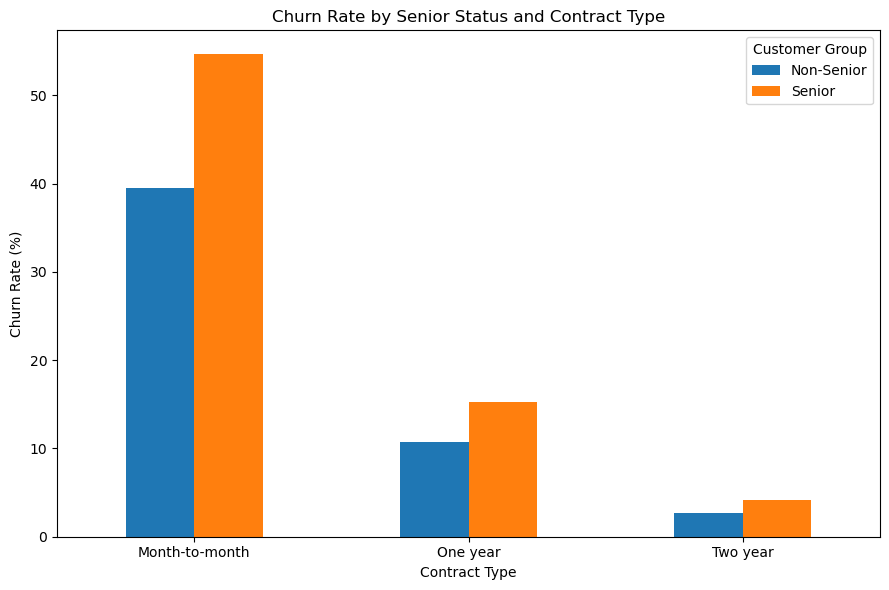

In [30]:
senior_contract_churn.T.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Churn Rate by Senior Status and Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(
    ["Non-Senior", "Senior"],
    title="Customer Group"
)

plt.tight_layout()
plt.show()

### Key Finding

The highest observed churn rate occurred among **senior customers on month-to-month contracts**, at **54.65%**.

For comparison:

- Non-senior + Month-to-month: **39.57%**
- Senior + Month-to-month: **54.65%**
- Senior + One year: **15.26%**
- Senior + Two year: **4.14%**

Senior customers were also substantially more concentrated in month-to-month contracts.

### Business Implication

The combination of senior status and month-to-month contracting represents a potentially high-risk customer segment.

Rather than targeting customers based on senior status alone, retention teams could prioritize senior customers who are also on month-to-month contracts for proactive engagement.

Potential interventions could include:

- Personalized customer support
- Contract and pricing reviews
- Service education
- Proactive satisfaction checks
- Relevant loyalty or contract-conversion offers

> **Analytical caution:** These findings show associations within the dataset. They do not establish that contract type or senior status independently causes churn.

### 3.7 Churn by Internet Service

Customer churn was analyzed across internet service categories to determine whether the type of internet service is associated with differences in observed churn.

The analysis compares customers using DSL, fiber optic, and customers without internet service.

In [31]:
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_churn_rate

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

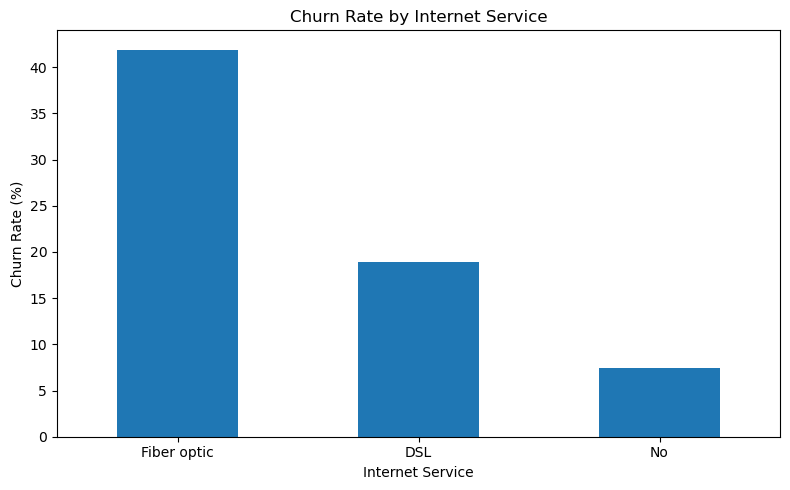

In [32]:
plt.figure(figsize=(8, 5))

internet_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

Churn varied substantially across internet service categories:

- **Fiber optic:** 41.89%
- **DSL:** 18.96%
- **No internet service:** 7.40%

Customers with fiber-optic service had the highest observed churn rate among the three groups.

### Business Implication

The fiber-optic customer segment warrants further investigation.

Potential areas of investigation include:

- Service quality and reliability
- Pricing and perceived value
- Technical support
- Customer expectations
- Service onboarding and experience

The higher churn observed among fiber-optic customers should be treated as an association rather than evidence that fiber-optic service itself causes churn.

### 3.8 Churn by Internet Service and Contract Type

Internet service and contract type were analyzed together to identify customer segments with particularly high or low observed churn.

Examining these variables independently provides useful context, but combining them can reveal more actionable customer segments for retention planning.

In [33]:
internet_contract_churn = (
    df.groupby(
        ["InternetService", "Contract"],
        observed=True
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

internet_contract_churn

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,32.215863,9.298246,1.910828
Fiber optic,54.605263,19.294991,7.226107
No,18.893130,2.472527,0.783699


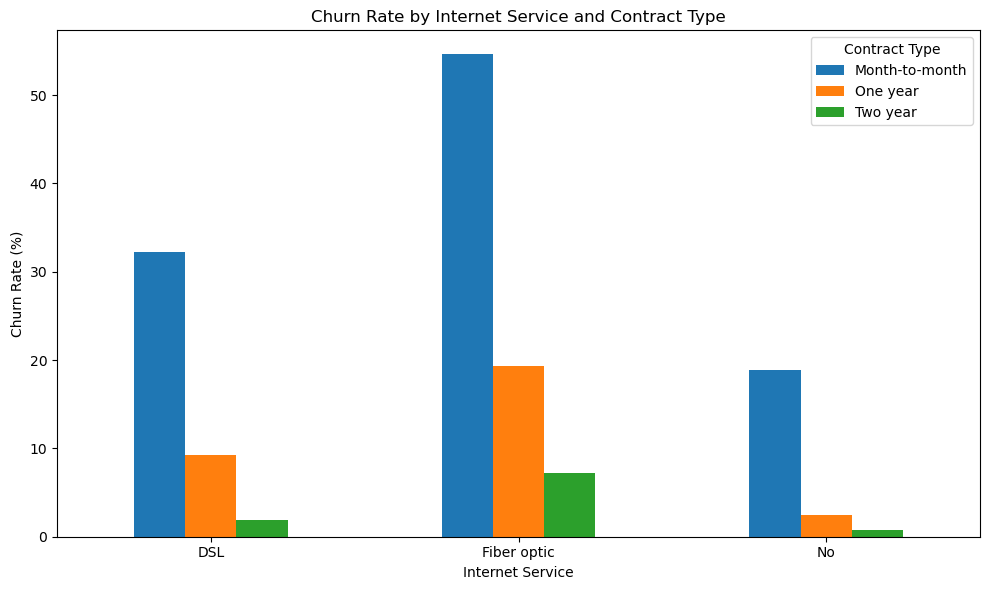

In [34]:
internet_contract_churn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Internet Service and Contract Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Contract Type")

plt.tight_layout()
plt.show()

### Key Finding

The combination of internet service and contract type revealed substantial differences in observed churn.

The highest-risk segment identified was:

### 🚨 Fiber Optic + Month-to-Month: 54.61% Churn

Other notable segments included:

- DSL + Month-to-month: **32.22%**
- Fiber optic + One year: **19.29%**
- Fiber optic + Two year: **7.23%**

Within the fiber-optic segment, the observed churn rate among month-to-month customers was approximately **47 percentage points higher** than among two-year customers.

### Business Implication

**Fiber-optic customers on month-to-month contracts should be considered a priority segment for further retention investigation.**

The business could investigate:

- Pricing and perceived value
- Service reliability and quality
- Technical support experience
- Customer onboarding
- Contract conversion opportunities
- Customer satisfaction

A targeted retention strategy could prioritize this segment rather than applying the same intervention to the entire customer base.

> **Analytical caution:** The large difference between contract groups is an observed association. This analysis does not establish that contract length or internet service causes churn.

### 3.9 Churn by Payment Method

Customer churn was analyzed across payment methods to determine whether different payment channels are associated with different observed churn rates.

Understanding payment behavior can help identify potential billing or payment-experience segments that may warrant further investigation.

In [35]:
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

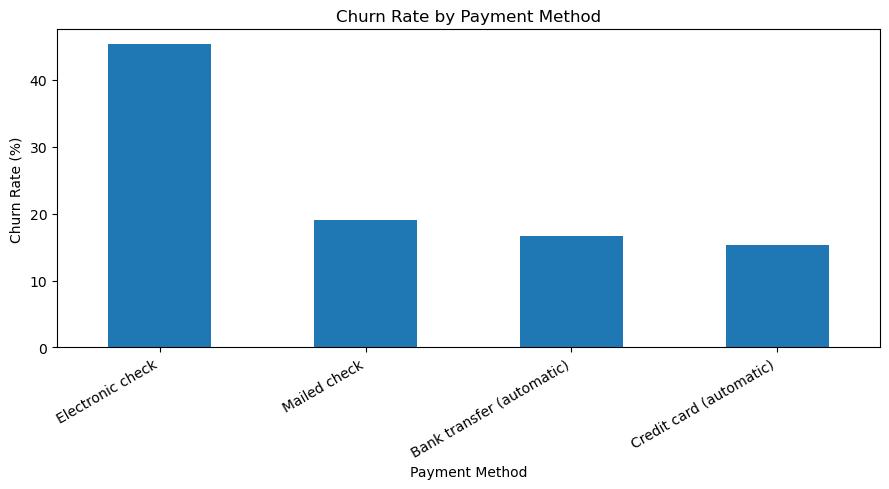

In [36]:
plt.figure(figsize=(9, 5))

payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Key Finding

Customers using **electronic checks** had the highest observed churn rate at **45.29%**.

This was substantially higher than:

- Mailed check: **19.11%**
- Bank transfer (automatic): **16.71%**
- Credit card (automatic): **15.24%**

### Business Implication

The electronic-check segment warrants further investigation into the customer billing and payment experience.

Potential areas to investigate include:

- Payment friction
- Billing disputes
- Payment failures
- Pricing or perceived value
- Differences in customer characteristics

The business could also evaluate whether encouraging convenient automatic payment options improves the customer experience.

> **Analytical caution:** Payment method is associated with churn in this dataset, but the analysis does not establish that a particular payment method causes customers to churn.

### 3.10 Churn by Paperless Billing

Customer churn was analyzed across paperless billing categories to determine whether billing preferences are associated with differences in observed churn rates.

This analysis provides another view of customer billing behavior and helps identify segments that may warrant further investigation.

In [37]:
paperless_churn_rate = (
    df.groupby("PaperlessBilling")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

paperless_churn_rate

PaperlessBilling
Yes    33.565092
No     16.330084
Name: Churn, dtype: float64

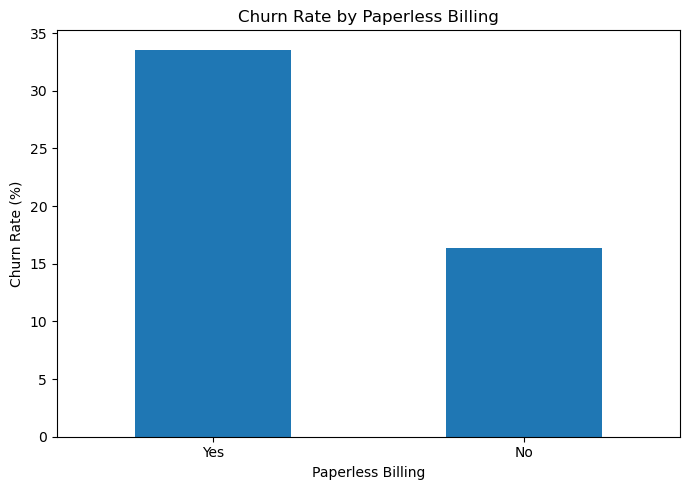

In [38]:
plt.figure(figsize=(7, 5))

paperless_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

Customers using paperless billing had a higher observed churn rate:

- **Paperless billing:** 33.57%
- **No paperless billing:** 16.33%

The difference between the two groups is substantial.

### Business Implication

Paperless billing status may be useful as a customer segmentation signal when combined with other characteristics.

However, paperless billing should not be interpreted as a direct cause of churn. The difference may reflect underlying differences in customer profiles, contract types, payment methods, services, or other factors.

Further analysis is required to determine whether billing experience contributes meaningfully to customer retention.

## 4. Financial & Revenue-at-Risk Analysis

Customer churn has a direct financial dimension because customers who leave the business are no longer associated with recurring monthly charges.

To quantify the potential financial exposure represented by churn, the total `MonthlyCharges` associated with customers who have churned were calculated.

Because this dataset is a cross-sectional snapshot rather than a time-series revenue dataset, this measure is treated as a **revenue-at-risk proxy** rather than a forecast of actual future revenue loss.

### 4.1 Monthly Charges Associated with Churned Customers

The total monthly charges associated with customers classified as churned were calculated to estimate the scale of recurring charges represented by the churned customer base.

In [39]:
churned_revenue = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

churned_revenue

np.float64(139130.85)

In [40]:
total_monthly_charges = df["MonthlyCharges"].sum()

total_monthly_charges

np.float64(456116.6)

In [41]:
revenue_at_risk_pct = (
    churned_revenue / total_monthly_charges
) * 100

revenue_at_risk_pct

np.float64(30.503351555282137)

### Key Finding

Customers who had churned were associated with approximately **$139,130.85 in monthly charges**.

These charges represented approximately **30.5% of the total monthly charges** across the customer base.

This indicates that churn is not only a customer-count problem but also represents meaningful financial exposure within the dataset.

### Business Implication

The results support a more targeted approach to customer retention.

Instead of treating every customer as equally valuable from a retention perspective, the business could combine:

- Predicted churn risk
- Monthly charges
- Contract type
- Customer tenure
- Service characteristics

to prioritize customers where the potential financial impact of churn is greatest.

> **Important:** The $139,130.85 figure should not be interpreted as actual monthly revenue lost. It represents the monthly charges associated with customers classified as churned in this cross-sectional dataset and is therefore used as a revenue-at-risk proxy.

## 5. Predictive Churn Modeling

The exploratory analysis identified several customer characteristics associated with higher churn rates, including contract type, tenure, internet service, payment method, and senior-citizen status.

To complement the descriptive analysis, a predictive model will be developed to estimate the likelihood that a customer will churn.

A **Logistic Regression** model is used as the initial baseline because it is interpretable and well suited to binary classification. The model will also allow the analysis to identify which customer characteristics are most strongly associated with churn risk.

The modeling workflow will include:

1. Preparing the target variable
2. Separating features from the target
3. Encoding categorical variables
4. Splitting the data into training and testing sets
5. Training the Logistic Regression model
6. Evaluating model performance
7. Interpreting the model's key factors

### 5.1 Target Variable Preparation

The `Churn` column contains the outcome we want to predict. It will be converted from categorical values into binary values:

- `No` → `0`
- `Yes` → `1`

In [42]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 5.2 Feature Preparation

The `customerID` column is an identifier and does not provide useful predictive information, so it will be excluded from the model.

The remaining variables will be separated into:

- **Features (`X`)** — customer characteristics used to predict churn
- **Target (`y`)** — whether the customer churned

In [43]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

X.shape, y.shape

((7043, 20), (7043,))

### 5.3 Handling Categorical Variables

The dataset contains both numerical and categorical features.

Logistic Regression requires numerical input, so categorical variables will be converted into numerical representations using **one-hot encoding**.

The original categorical columns will be replaced with binary indicator columns. `drop_first=True` is used to avoid redundant categories and reduce multicollinearity.

In [44]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))

Categorical features: 15
Numerical features: 5


In [45]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X.shape

(7043, 31)

In [46]:
X.dtypes.value_counts()

bool        26
int64        2
float64      2
category     1
Name: count, dtype: int64

### 5.4 Train/Test Split

The dataset is divided into training and testing sets using an 80/20 split.

The training set will be used to fit the predictive model, while the testing set will be reserved for evaluating performance on unseen data.

Stratification is applied to preserve the proportion of churned and retained customers in both sets.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 31)
X_test: (1409, 31)
y_train: (5634,)
y_test: (1409,)


In [49]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


### 5.5 Training the Logistic Regression Model

Logistic Regression is used as the baseline classification model for predicting customer churn.

The model estimates the probability that a customer belongs to the churn class (`1`) based on the available customer characteristics.

The model is intentionally used as a baseline because its coefficients are relatively easy to interpret, allowing the analysis to connect predictive results back to business factors associated with churn.

In [50]:
X = X.drop(columns=["TenureGroup"])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

In [53]:
X_train.columns.difference(X_test.columns)

Index([], dtype='object')

In [54]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [56]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

### 5.6 Model Performance Evaluation

The model is evaluated using the unseen testing dataset.

A confusion matrix is used to compare the model's predictions with the actual churn outcomes.

The matrix identifies four outcomes:

- **True Negative (TN):** Customers correctly predicted to stay
- **False Positive (FP):** Customers predicted to churn who actually stayed
- **False Negative (FN):** Customers predicted to stay who actually churned
- **True Positive (TP):** Customers correctly predicted to churn

Understanding these outcomes is important because missing a customer who is likely to churn can represent a missed retention opportunity.

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[927, 108],
       [165, 209]])

### 5.7 Classification Metrics

Several classification metrics are used to evaluate the model from different perspectives.

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many customers predicted to churn actually churned.
- **Recall** measures how many of the customers who actually churned were successfully identified.
- **F1-score** balances precision and recall.

For customer retention, recall is particularly important because failing to identify a customer who eventually churns represents a missed opportunity for intervention.

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")

Accuracy:  80.62%
Precision: 65.93%
Recall:    55.88%
F1-score:  60.49%


### 5.8 Business Interpretation of Model Performance

The Logistic Regression model achieved an accuracy of approximately **80.6%** on the testing dataset.

The model's churn precision was approximately **65.9%**, meaning that when the model predicted a customer would churn, it was correct about two-thirds of the time.

The churn recall was approximately **55.9%**, meaning the model identified roughly 56% of the customers who actually churned. This also means that some customers who eventually churned were not identified by the model.

The F1-score of approximately **60.5%** reflects the balance between precision and recall.

From a business perspective, the model provides a useful starting point for customer-retention prioritization. However, it should not be treated as a definitive decision-making system. Missing potential churners remains an important limitation, so future model improvements could focus on increasing recall while maintaining acceptable precision.

Overall, the model demonstrates that customer-level churn prediction is feasible using the available customer attributes, while also highlighting the need for careful evaluation before deploying a predictive retention strategy.

### 5.9 ROC-AUC Evaluation

The ROC curve evaluates how well the model distinguishes between customers who churn and those who remain.

The **Area Under the ROC Curve (ROC-AUC)** summarizes this performance:

- A value of 0.5 indicates performance similar to random guessing.
- A value closer to 1.0 indicates stronger ability to distinguish between the two classes.

The ROC-AUC score is useful because it evaluates the model across different classification thresholds rather than relying on a single prediction threshold.

In [59]:
from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print(f"ROC-AUC: {roc_auc:.2%}")

ROC-AUC: 84.25%


### 5.10 ROC Curve

The ROC curve visualizes the model's ability to distinguish between customers who churn and customers who remain.

The curve plots the **True Positive Rate** against the **False Positive Rate** across different classification thresholds.

A model with stronger discriminatory ability will generally produce a curve that is further above the diagonal reference line.

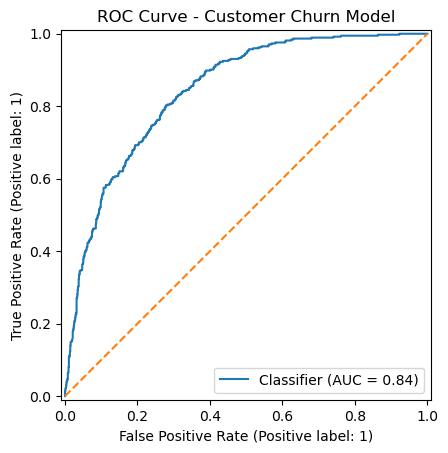

In [60]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Customer Churn Model")
plt.show()

### 5.11 Model Feature Interpretation

Logistic Regression coefficients provide insight into how individual features are associated with the predicted likelihood of churn.

- A **positive coefficient** indicates a positive association with churn risk.
- A **negative coefficient** indicates a negative association with churn risk.
- The magnitude of the coefficient indicates the strength of the association within the model.

These results should be interpreted as **associations, not causal relationships**. They describe patterns identified by the model while holding the other included features constant.

In [61]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute_Coefficient
25,Contract_Two year,-1.328492,1.328492
10,InternetService_Fiber optic,1.314698,1.314698
24,Contract_One year,-0.686113,0.686113
21,StreamingTV_Yes,0.428453,0.428453
23,StreamingMovies_Yes,0.427765,0.427765
9,MultipleLines_Yes,0.391426,0.391426
28,PaymentMethod_Electronic check,0.379467,0.379467
26,PaperlessBilling_Yes,0.372866,0.372866
13,OnlineSecurity_Yes,-0.322514,0.322514
8,MultipleLines_No phone service,0.282767,0.282767


### 5.12 Odds Ratio Interpretation

Logistic Regression coefficients can be converted into odds ratios to make the model results easier to interpret.

An odds ratio:

- Greater than `1` indicates higher modeled odds of churn relative to the reference category.
- Less than `1` indicates lower modeled odds of churn relative to the reference category.
- Equal to `1` indicates no difference in modeled odds.

Odds ratios represent associations within the model and should not be interpreted as evidence of causation.

In [62]:
coefficients["Odds_Ratio"] = np.exp(
    coefficients["Coefficient"]
)

coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute_Coefficient,Odds_Ratio
25,Contract_Two year,-1.328492,1.328492,0.264876
10,InternetService_Fiber optic,1.314698,1.314698,3.723628
24,Contract_One year,-0.686113,0.686113,0.503530
21,StreamingTV_Yes,0.428453,0.428453,1.534881
23,StreamingMovies_Yes,0.427765,0.427765,1.533825
9,MultipleLines_Yes,0.391426,0.391426,1.479088
28,PaymentMethod_Electronic check,0.379467,0.379467,1.461506
26,PaperlessBilling_Yes,0.372866,0.372866,1.451890
13,OnlineSecurity_Yes,-0.322514,0.322514,0.724326
8,MultipleLines_No phone service,0.282767,0.282767,1.326796


### 5.13 Key Factors Associated with Customer Churn

The strongest positive and negative Logistic Regression coefficients are visualized to highlight the customer characteristics most strongly associated with modeled churn risk.

Positive coefficients indicate higher modeled odds of churn, while negative coefficients indicate lower modeled odds relative to the relevant reference categories.

The visualization provides a concise view of the model's key signals and complements the earlier exploratory analysis.

In [63]:
top_positive = coefficients.sort_values(
    "Coefficient",
    ascending=False
).head(10)

top_negative = coefficients.sort_values(
    "Coefficient",
    ascending=True
).head(10)

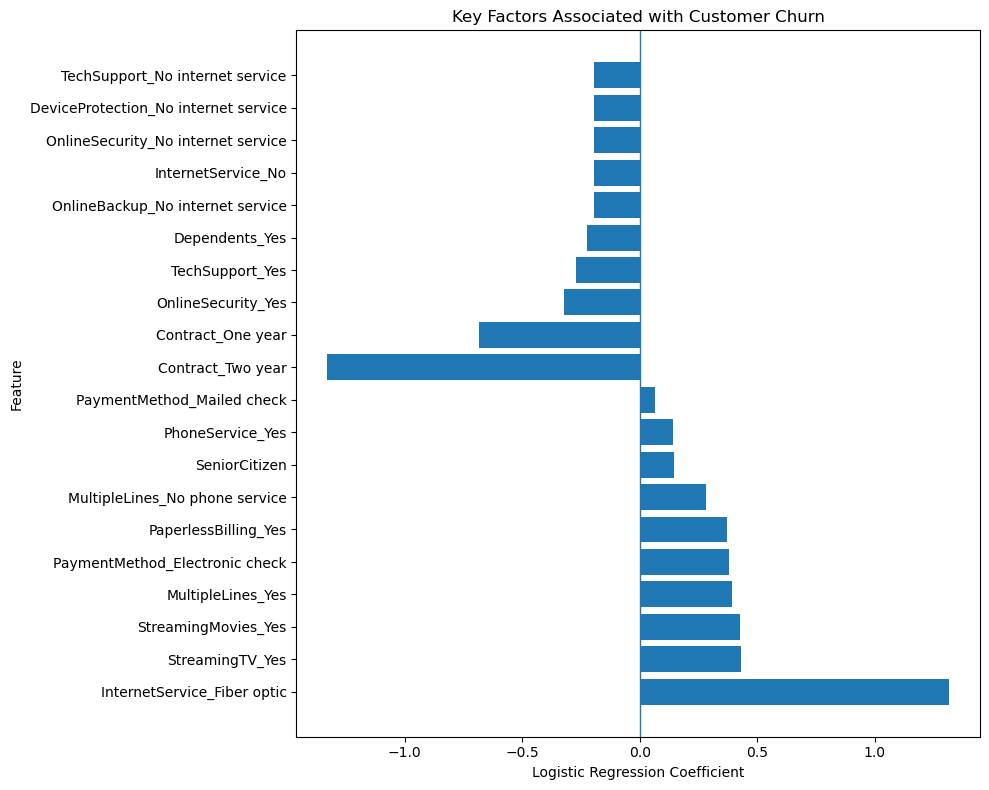

In [64]:
plot_data = pd.concat([
    top_positive,
    top_negative
])

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Key Factors Associated with Customer Churn")

plt.tight_layout()
plt.show()

### 5.14 Customer Churn Risk Dataset

To make the model results more useful for business decision-making, the testing predictions are combined with the model's estimated probability of churn.

The resulting dataset provides three important signals:

- **Actual Churn** — whether the customer actually churned in the testing data
- **Predicted Churn** — the model's classification at the default probability threshold
- **Churn Probability** — the model's estimated probability that the customer will churn

The churn probability provides a more granular risk signal than a simple Yes/No prediction and can support customer-retention prioritization.

In [65]:
churn_risk = X_test.copy()

churn_risk["Actual_Churn"] = y_test.values
churn_risk["Predicted_Churn"] = y_pred
churn_risk["Churn_Probability"] = y_probability

churn_risk.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn,Churn_Probability
437,0,72,114.05,8468.20,True,True,True,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,True,False,False,0,0,0.047605
2280,1,8,100.15,908.55,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,True,True,False,False,0,1,0.682883
2235,0,41,78.35,3211.20,False,True,True,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,True,True,False,False,0,0,0.058699
4460,0,18,78.20,1468.75,True,True,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,0,0,0.400377
3761,0,72,82.65,5919.35,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,True,True,False,False,0,0,0.021603


### 5.15 Business-Focused Customer Risk Table

The model predictions are combined with selected customer attributes from the original dataset to create a business-friendly retention risk table.

This allows the business to move from model predictions to actionable customer-level insights by considering both churn probability and customer characteristics.

The table can support retention prioritization by highlighting customers with elevated churn probability and meaningful recurring charges.

In [66]:
risk_customers = df.loc[
    X_test.index,
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "InternetService",
        "PaymentMethod",
        "SeniorCitizen"
    ]
].copy()

risk_customers["Actual_Churn"] = y_test
risk_customers["Predicted_Churn"] = y_pred
risk_customers["Churn_Probability"] = y_probability

risk_customers.head()

,customerID,tenure,Contract,MonthlyCharges,InternetService,PaymentMethod,SeniorCitizen,Actual_Churn,Predicted_Churn,Churn_Probability
437,4376-KFVRS,72,Two year,114.05,Fiber optic,Credit card (automatic),0,0,0,0.047605
2280,2754-SDJRD,8,Month-to-month,100.15,Fiber optic,Credit card (automatic),1,0,1,0.682883
2235,9917-KWRBE,41,One year,78.35,DSL,Credit card (automatic),0,0,0,0.058699
4460,0365-GXEZS,18,Month-to-month,78.20,Fiber optic,Electronic check,0,0,0,0.400377
3761,9385-NXKDA,72,Two year,82.65,DSL,Credit card (automatic),0,0,0,0.021603


### 5.16 High-Risk Customer Segmentation

Customers with an estimated churn probability of **70% or higher** are classified as high-risk for this analysis.

This threshold is used as an illustrative business rule rather than a universal cutoff. In a production environment, the threshold should be selected using business considerations such as retention campaign capacity, intervention costs, customer value, and the relative cost of false positives and false negatives.

The high-risk segment can help the retention team prioritize customers who may warrant proactive engagement.

In [67]:
high_risk_customers = risk_customers[
    risk_customers["Churn_Probability"] >= 0.70
].copy()

high_risk_customers.shape

(93, 10)

### 5.17 Highest-Risk Customer Prioritization

The high-risk customer segment is ranked by estimated churn probability.

This allows the retention team to identify customers with the strongest modeled risk signals and prioritize potential interventions accordingly.

In [68]:
high_risk_customers = high_risk_customers.sort_values(
    "Churn_Probability",
    ascending=False
)

high_risk_customers.head(10)

,customerID,tenure,Contract,MonthlyCharges,InternetService,PaymentMethod,SeniorCitizen,Actual_Churn,Predicted_Churn,Churn_Probability
3380,5178-LMXOP,1,Month-to-month,95.10,Fiber optic,Electronic check,1,1,1,0.854055
6866,0295-PPHDO,1,Month-to-month,95.45,Fiber optic,Electronic check,0,1,1,0.830614
2631,6861-XWTWQ,7,Month-to-month,99.25,Fiber optic,Electronic check,1,1,1,0.827153
6365,8884-ADFVN,7,Month-to-month,101.95,Fiber optic,Electronic check,1,1,1,0.820069
4585,1069-XAIEM,1,Month-to-month,85.05,Fiber optic,Electronic check,1,1,1,0.818736
3346,2545-EBUPK,2,Month-to-month,84.05,Fiber optic,Electronic check,1,0,1,0.817849
3727,9057-SIHCH,3,Month-to-month,96.60,Fiber optic,Electronic check,0,1,1,0.815822
2797,6023-YEBUP,3,Month-to-month,100.95,Fiber optic,Electronic check,0,1,1,0.815605
6894,1400-MMYXY,3,Month-to-month,105.90,Fiber optic,Electronic check,1,1,1,0.814168
935,6630-UJZMY,4,Month-to-month,83.25,Fiber optic,Electronic check,1,0,1,0.812563


### 5.18 Risk and Financial Exposure

Churn probability is combined with monthly charges to create a simple customer prioritization measure.

The measure is calculated as:

**Potential Monthly Revenue Exposure = Churn Probability × Monthly Charges**

This score is intended to help prioritize retention efforts by considering both the likelihood of churn and the recurring monthly charges associated with the customer.

It should not be interpreted as a forecast of actual revenue loss. It is a prioritization measure based on the model's estimated churn probability and the customer's current monthly charges.

In [69]:
high_risk_customers["Potential_Monthly_Revenue_Exposure"] = (
    high_risk_customers["Churn_Probability"]
    * high_risk_customers["MonthlyCharges"]
)

high_risk_customers[
    [
        "customerID",
        "Churn_Probability",
        "MonthlyCharges",
        "Potential_Monthly_Revenue_Exposure"
    ]
].head(10)

,customerID,Churn_Probability,MonthlyCharges,Potential_Monthly_Revenue_Exposure
3380,5178-LMXOP,0.854055,95.10,81.220647
6866,0295-PPHDO,0.830614,95.45,79.282076
2631,6861-XWTWQ,0.827153,99.25,82.094939
6365,8884-ADFVN,0.820069,101.95,83.606008
4585,1069-XAIEM,0.818736,85.05,69.633499
3346,2545-EBUPK,0.817849,84.05,68.740239
3727,9057-SIHCH,0.815822,96.60,78.808433
2797,6023-YEBUP,0.815605,100.95,82.335360
6894,1400-MMYXY,0.814168,105.90,86.220368
935,6630-UJZMY,0.812563,83.25,67.645829


### 5.19 Retention Priority Ranking

The high-risk customers are ranked using the Potential Monthly Revenue Exposure measure.

This prioritization combines modeled churn probability with monthly charges, helping identify customers who represent both elevated churn risk and relatively high recurring financial exposure.

The ranking is intended to support retention prioritization rather than predict actual revenue loss.

In [70]:
priority_customers = high_risk_customers.sort_values(
    "Potential_Monthly_Revenue_Exposure",
    ascending=False
)

priority_customers[
    [
        "customerID",
        "Contract",
        "tenure",
        "MonthlyCharges",
        "Churn_Probability",
        "Potential_Monthly_Revenue_Exposure"
    ]
].head(10)

,customerID,Contract,tenure,MonthlyCharges,Churn_Probability,Potential_Monthly_Revenue_Exposure
6894,1400-MMYXY,Month-to-month,3,105.90,0.814168,86.220368
6365,8884-ADFVN,Month-to-month,7,101.95,0.820069,83.606008
2797,6023-YEBUP,Month-to-month,3,100.95,0.815605,82.335360
2631,6861-XWTWQ,Month-to-month,7,99.25,0.827153,82.094939
3956,4587-VVTOX,Month-to-month,6,105.30,0.771436,81.232181
3380,5178-LMXOP,Month-to-month,1,95.10,0.854055,81.220647
2448,9221-OTIVJ,Month-to-month,14,104.85,0.764474,80.155144
6866,0295-PPHDO,Month-to-month,1,95.45,0.830614,79.282076
2294,2027-FECZV,Month-to-month,12,106.70,0.740198,78.979138
3727,9057-SIHCH,Month-to-month,3,96.60,0.815822,78.808433


### 5.20 High-Risk Segment Summary

The high-risk segment contains customers with a modeled churn probability of at least 70%.

The segment is summarized using customer count, average monthly charges, total monthly charges, and total potential monthly revenue exposure.

This provides a high-level view of the scale and financial significance of the customers identified for potential retention intervention.

In [71]:
high_risk_summary = {
    "High_Risk_Customers": len(high_risk_customers),
    "Average_Monthly_Charges": high_risk_customers["MonthlyCharges"].mean(),
    "Total_Monthly_Charges": high_risk_customers["MonthlyCharges"].sum(),
    "Total_Potential_Monthly_Revenue_Exposure": (
        high_risk_customers[
            "Potential_Monthly_Revenue_Exposure"
        ].sum()
    )
}

high_risk_summary

{'High_Risk_Customers': 93,
 'Average_Monthly_Charges': np.float64(83.81129032258065),
 'Total_Monthly_Charges': np.float64(7794.45),
 'Total_Potential_Monthly_Revenue_Exposure': np.float64(5861.36819748595)}

### 5.21 Highest-Priority Customers by Financial Exposure

The highest-priority customers are visualized based on Potential Monthly Revenue Exposure.

This highlights customers where elevated modeled churn risk coincides with relatively high monthly charges, providing a practical basis for prioritizing retention interventions.

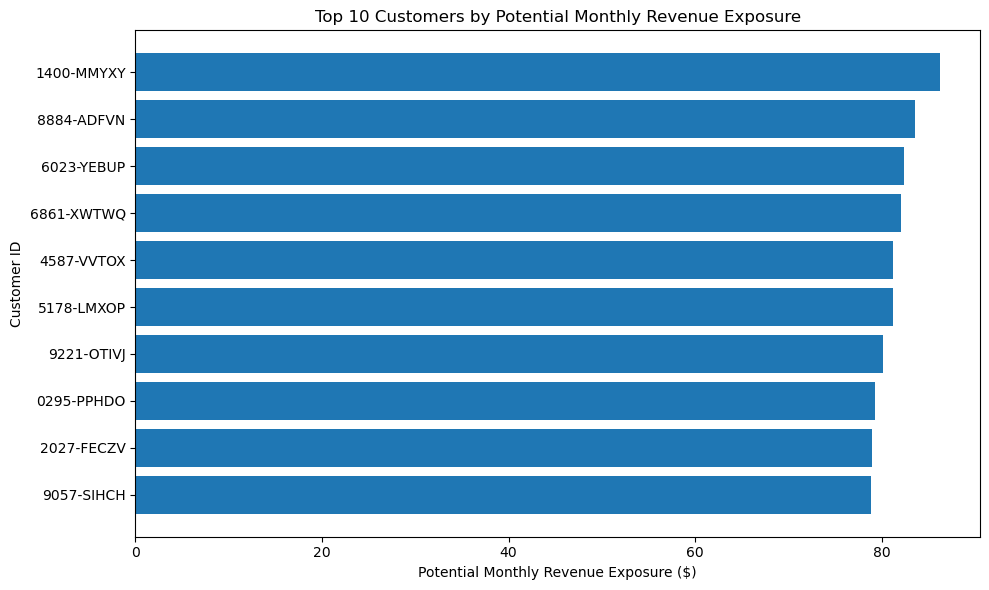

In [72]:
top_priority = priority_customers.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_priority["customerID"],
    top_priority["Potential_Monthly_Revenue_Exposure"]
)

plt.xlabel("Potential Monthly Revenue Exposure ($)")
plt.ylabel("Customer ID")
plt.title("Top 10 Customers by Potential Monthly Revenue Exposure")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 5.22 Key Business Findings

The analysis and predictive modeling produced several key findings:

### 1. Churn is a significant customer-retention challenge

Approximately **26.5% of customers had churned**, meaning roughly one in every four customers in the dataset had left the company.

This indicates that customer retention represents a meaningful business opportunity.

### 2. Contract structure is strongly associated with churn

Month-to-month customers had a churn rate of approximately **42.7%**, compared with **11.3%** for one-year contracts and **2.8%** for two-year contracts.

Contract structure is therefore one of the strongest segmentation signals identified in the analysis.

### 3. Early-tenure customers show elevated churn

Customers in their first 12 months had a churn rate of approximately **47.4%**, compared with approximately **9.5%** among customers with more than four years of tenure.

This suggests that the early customer lifecycle is an important period for retention efforts.

### 4. Fiber optic customers show elevated churn

Fiber optic customers had a churn rate of approximately **41.9%**, substantially higher than DSL customers at approximately **19.0%**.

The combination of **Fiber optic + Month-to-month contract** produced a particularly high churn rate of approximately **54.6%**.

### 5. Payment method is associated with different churn levels

Customers using **electronic check** had the highest observed churn rate at approximately **45.3%**.

This pattern suggests that the payment journey and customer experience around billing should be investigated further.

### 6. Churn represents meaningful financial exposure

Customers classified as churned were associated with approximately **$139,130.85 in monthly charges**, representing approximately **30.5% of total monthly charges** in the dataset.

This is treated as a revenue-at-risk proxy rather than a forecast of actual revenue loss.

### 7. The predictive model provides useful risk signals

The Logistic Regression model achieved approximately:

- **80.6% accuracy**
- **65.9% precision**
- **55.9% recall**
- **60.5% F1-score**
- **84.3% ROC-AUC**

The model successfully identifies meaningful churn patterns, but it does not capture every customer who eventually churns.

### 8. Risk and customer value can be combined

The analysis demonstrates that churn prioritization can go beyond simply identifying customers who are likely to leave.

Combining **churn probability with monthly charges** creates a practical prioritization framework that can help retention teams focus on customers who represent both elevated modeled risk and meaningful recurring financial exposure.

## 5.23 Retention Strategy & Business Recommendations

The findings suggest that retention efforts should be targeted rather than applied uniformly across the customer base.

### Recommendation 1 — Strengthen the first 12 months

Customers with less than 12 months of tenure showed the highest observed churn rate at approximately **47.4%**.

The business should consider:

- Structured onboarding journeys
- Early satisfaction check-ins
- Proactive support during the first few months
- Clear communication of product value
- Early identification of dissatisfied customers

### Recommendation 2 — Prioritize month-to-month customers

Month-to-month customers had substantially higher churn than customers on longer-term contracts.

Retention teams could consider:

- Loyalty incentives
- Contract upgrade offers
- Personalized retention offers
- Clear communication of the value of longer-term plans

Any incentive strategy should be evaluated against its cost and potential customer lifetime value.

### Recommendation 3 — Investigate the Fiber optic customer experience

Fiber optic customers showed substantially higher churn, with the **Fiber optic + Month-to-month** segment reaching approximately **54.6% churn**.

The business should investigate whether this pattern is associated with:

- Service reliability
- Pricing or perceived value
- Installation experience
- Technical support
- Customer expectations
- Competitive alternatives

The analysis identifies this segment as a priority for investigation, but additional operational data would be required to determine the underlying cause.

### Recommendation 4 — Investigate electronic-check customers

Electronic-check customers had an observed churn rate of approximately **45.3%**, the highest among the payment methods analyzed.

The business could investigate:

- Payment friction
- Billing experience
- Failed or delayed payments
- Customer preferences
- Communication around billing

Automated payment options could potentially be tested as part of a controlled retention experiment rather than assumed to be the solution.

### Recommendation 5 — Use predictive risk to prioritize retention activity

The Logistic Regression model can be used as a **prioritization tool** rather than an automatic decision-maker.

Customers with elevated churn probability can be ranked alongside customer value indicators such as monthly charges.

This creates a more targeted retention workflow:

**Identify risk → Assess customer value → Investigate likely drivers → Select intervention → Measure outcome**

### Recommendation 6 — Measure retention interventions

Any retention strategy should be evaluated using measurable outcomes such as:

- Retention rate
- Churn reduction
- Customer lifetime value
- Revenue retained
- Offer acceptance rate
- Cost per retained customer

This would allow the business to determine which interventions actually improve retention rather than relying solely on observed correlations.

## 5.24 Limitations & Responsible Use

Several limitations should be considered when interpreting the results of this analysis.

### Dataset limitations

The dataset is a public benchmark/fictitious telecommunications dataset rather than proprietary customer data from a real company. The findings should therefore be treated as a realistic analytical case study rather than direct evidence about an actual telecommunications business.

### Cross-sectional data

The dataset represents a snapshot of customer information rather than a longitudinal record of customer behavior over time.

As a result, the analysis can identify patterns and associations but cannot establish how customer behavior changes over time.

### Association does not imply causation

Observed differences in churn rates and model coefficients represent associations within the dataset.

For example, the higher churn rate observed among Fiber optic customers does not demonstrate that Fiber optic service itself causes customers to churn.

Further investigation and controlled experimentation would be required to establish causal relationships.

### Model limitations

The Logistic Regression model achieved useful predictive performance, but it did not identify every customer who churned.

The model therefore should be used as a **decision-support and prioritization tool**, rather than as an automated decision-maker.

### Revenue-at-risk limitation

The estimated revenue-at-risk measure is based on monthly charges associated with customers classified as churned.

It should not be interpreted as actual future revenue loss because the dataset is cross-sectional and does not provide a complete revenue forecasting framework.

### Additional data that could improve the analysis

A production churn solution could be strengthened with additional information such as:

- Customer support interactions
- Service outages
- Complaints
- Billing history
- Payment failures
- Discounts and promotions
- Customer satisfaction scores
- Customer lifetime value
- Historical changes in usage and charges
- Cancellation reasons

These additional variables could improve both predictive performance and the business's ability to understand the underlying drivers of churn.

### Responsible use

Customer churn predictions should be used to support helpful and fair customer-retention interventions.

Predictions should not be treated as certainty or used to unfairly restrict services, pricing, or access to customers.

Model performance and outcomes should be monitored regularly to ensure that the system remains accurate and appropriate for its intended business purpose.

## 5.25 Conclusion & Executive Takeaway

This analysis demonstrates how customer data can be transformed into actionable insights for churn reduction and retention strategy.

The analysis identified several important churn patterns. Month-to-month customers showed substantially higher churn than customers on longer-term contracts, while customers in their first 12 months had the highest observed churn rates. Fiber optic customers also demonstrated elevated churn, particularly when combined with month-to-month contracts. Differences were also observed across payment methods, with electronic-check customers showing the highest churn rate.

The financial analysis demonstrated that customers classified as churned were associated with approximately **$139,130.85 in monthly charges**, representing approximately **30.5% of total monthly charges** in the dataset. This was used as a revenue-at-risk proxy rather than a forecast of actual revenue loss.

The Logistic Regression model achieved an **80.6% accuracy** and **84.3% ROC-AUC**, demonstrating useful predictive capability while also highlighting the limitations of predicting customer churn from the available attributes.

The most practical application of the model is therefore not to predict churn with certainty, but to help the business **prioritize retention efforts**. Combining modeled churn probability with customer value indicators such as monthly charges provides a framework for identifying customers who may warrant proactive intervention.

### Executive Takeaway

The strongest retention opportunity lies in identifying **high-risk customers early**, particularly among vulnerable customer segments such as newer and month-to-month customers, and combining predictive risk with financial value when prioritizing retention activity.

The next stage of this work would be to operationalize these insights through an interactive business dashboard and test targeted retention interventions using measurable outcomes such as churn reduction, revenue retained, and customer lifetime value.